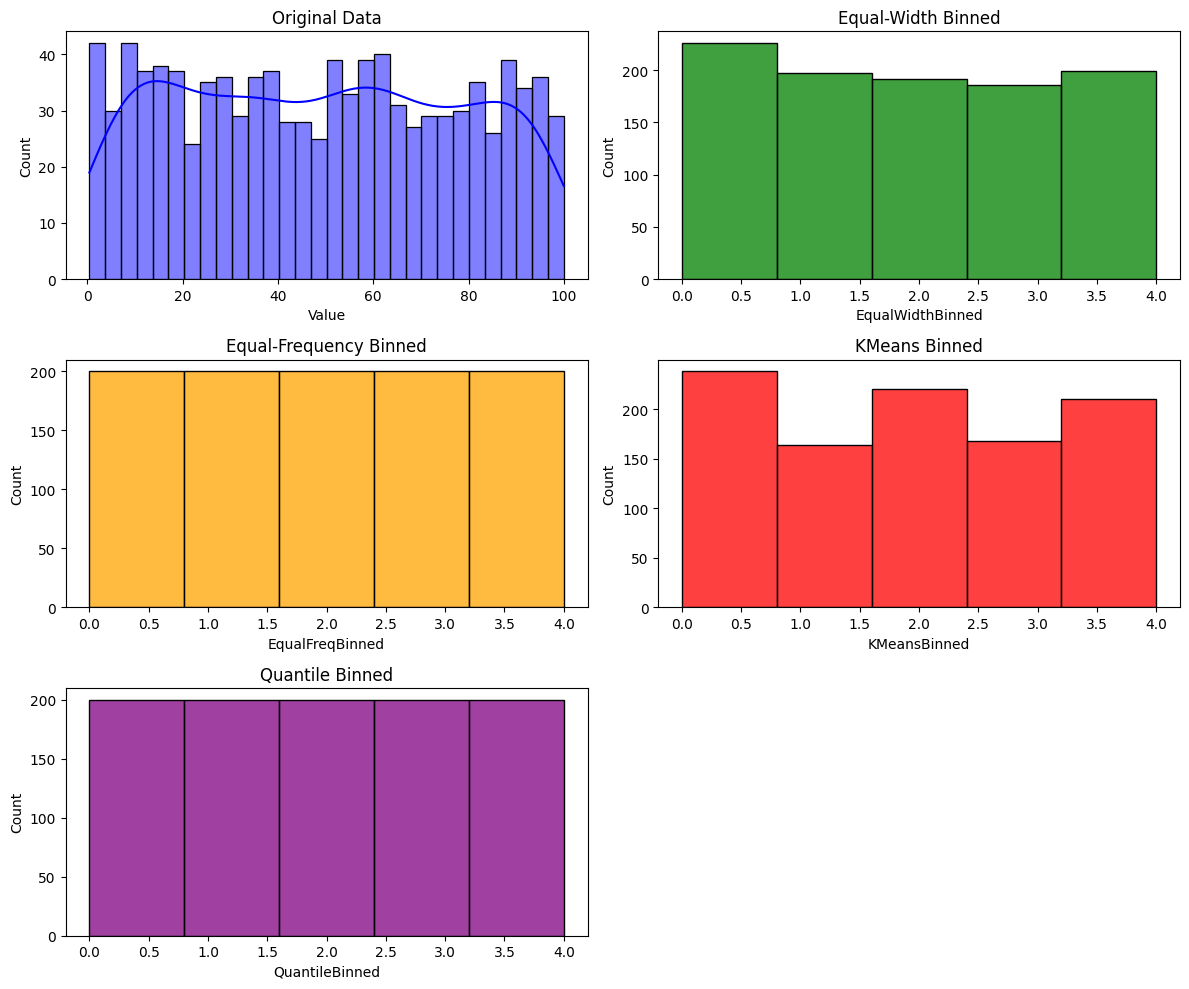

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import KBinsDiscretizer
import seaborn as sns

# Generating sample data (continuous variable)
np.random.seed(42)
data = np.random.rand(1000) * 100  # Continuous variable from 0 to 100

# Convert to DataFrame for easier handling
df = pd.DataFrame(data, columns=["Value"])

# 1. Equal-Width Binning
# We divide the range into a fixed number of bins.
n_bins = 5
df['EqualWidthBinned'] = pd.cut(df['Value'], bins=n_bins, labels=False)

# 2. Equal-Frequency Binning (each bin has the same number of data points)
df['EqualFreqBinned'] = pd.qcut(df['Value'], q=n_bins, labels=False)

# 3. KMeans Binning (using KMeans clustering for binning)
kmeans = KMeans(n_clusters=n_bins, random_state=42)
df['KMeansBinned'] = kmeans.fit_predict(df[['Value']])

# 4. Quantile Binning (using quantiles for binning)
quantiles = np.percentile(df['Value'], np.linspace(0, 100, n_bins + 1))
df['QuantileBinned'] = pd.cut(df['Value'], bins=quantiles, labels=False, include_lowest=True)

# Plotting histograms for each discretization method
plt.figure(figsize=(12, 10))

# Original continuous data histogram
plt.subplot(3, 2, 1)
sns.histplot(df['Value'], kde=True, color='blue', bins=30)
plt.title('Original Data')

# Equal-Width Binned data
plt.subplot(3, 2, 2)
sns.histplot(df['EqualWidthBinned'], kde=False, color='green', bins=n_bins)
plt.title('Equal-Width Binned')

# Equal-Frequency Binned data
plt.subplot(3, 2, 3)
sns.histplot(df['EqualFreqBinned'], kde=False, color='orange', bins=n_bins)
plt.title('Equal-Frequency Binned')

# KMeans Binned data
plt.subplot(3, 2, 4)
sns.histplot(df['KMeansBinned'], kde=False, color='red', bins=n_bins)
plt.title('KMeans Binned')

# Quantile Binned data
plt.subplot(3, 2, 5)
sns.histplot(df['QuantileBinned'], kde=False, color='purple', bins=n_bins)
plt.title('Quantile Binned')

plt.tight_layout()
plt.show()
